# Data Exploration

First, we inspect the dataset to check availability, sampling frequency, missingness, and basic statistical properties.

In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt


In [2]:
df = pd.read_csv('../data/raw/omni2_2016_2025_clean.csv')
df.head()

,datetime,year,doy,hour,B_scalar_nT,Bx_nT,By_gse_nT,Bz_gse_nT,By_gsm_nT,Bz_gsm_nT,temperature_K,density_cm3,speed_km_s,flow_pressure_nPa,electric_field_mV_m,plasma_beta,alfven_mach,Kp10,Dst_nT,AE_nT
0,2016-01-01 00:00:00,2016,1,0,15.0,4.9,-1.5,-14.1,2.2,-14.0,32589.0,2.0,463.0,0.88,6.48,0.06,2.2,60,-116,686
1,2016-01-01 01:00:00,2016,1,1,14.6,5.7,-2.2,-13.2,1.1,-13.3,30566.0,0.8,451.0,0.33,6.04,0.02,1.4,60,-114,574
2,2016-01-01 02:00:00,2016,1,2,13.9,4.5,-1.8,-13.0,1.1,-13.1,29278.0,1.1,450.0,0.45,5.89,0.04,1.7,60,-102,788
3,2016-01-01 03:00:00,2016,1,3,13.5,2.9,0.7,-13.1,3.1,-12.8,18090.0,1.7,434.0,0.64,5.60,0.06,2.1,53,-98,710
4,2016-01-01 04:00:00,2016,1,4,13.1,3.0,0.3,-12.7,2.0,-12.5,10371.0,0.9,430.0,0.33,5.42,0.03,1.6,53,-96,909


In [3]:
df['datetime'] = pd.to_datetime(df["datetime"])

df.head()
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 87672 entries, 0 to 87671
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   datetime             87672 non-null  datetime64[ns]
 1   year                 87672 non-null  int64         
 2   doy                  87672 non-null  int64         
 3   hour                 87672 non-null  int64         
 4   B_scalar_nT          87320 non-null  float64       
 5   Bx_nT                87320 non-null  float64       
 6   By_gse_nT            87320 non-null  float64       
 7   Bz_gse_nT            87320 non-null  float64       
 8   By_gsm_nT            87294 non-null  float64       
 9   Bz_gsm_nT            87294 non-null  float64       
 10  temperature_K        86921 non-null  float64       
 11  density_cm3          86850 non-null  float64       
 12  speed_km_s           86961 non-null  float64       
 13  flow_pressure_nPa    86846 non-

In [4]:
df['datetime'].duplicated().sum()
df["datetime"].diff().value_counts()

datetime
0 days 01:00:00    87671
Name: count, dtype: int64

In [5]:
# [REPLACE existing Cells 5 and 6]
missing = df.isna().sum()
missing_pct = df.isna().mean() * 100

missing_df = pd.DataFrame({
    "Missing Count": missing,
    "Missing Percentage (%)": missing_pct
})
missing_df = missing_df[missing_df["Missing Count"] > 0].sort_values("Missing Count", ascending=False)
display(missing_df.round(2))


,Missing Count,Missing Percentage (%)
plasma_beta,934,1.07
alfven_mach,895,1.02
flow_pressure_nPa,826,0.94
density_cm3,822,0.94
electric_field_mV_m,806,0.92
temperature_K,751,0.86
speed_km_s,711,0.81
By_gsm_nT,378,0.43
Bz_gsm_nT,378,0.43
Bz_gse_nT,352,0.40


In [6]:
for col in df.columns:
    n = df[col].isna().sum()
    if n > 0:
        print(f"{col}: {n} missing")

B_scalar_nT: 352 missing
Bx_nT: 352 missing
By_gse_nT: 352 missing
Bz_gse_nT: 352 missing
By_gsm_nT: 378 missing
Bz_gsm_nT: 378 missing
temperature_K: 751 missing
density_cm3: 822 missing
speed_km_s: 711 missing
flow_pressure_nPa: 826 missing
electric_field_mV_m: 806 missing
plasma_beta: 934 missing
alfven_mach: 895 missing


In [7]:
df["datetime"].diff().value_counts().head(10)

datetime
0 days 01:00:00    87671
Name: count, dtype: int64

In [8]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
datetime,87672,2020-12-31 11:30:00,2016-01-01 00:00:00,2018-07-02 05:45:00,2020-12-31 11:30:00,2023-07-02 17:15:00,2025-12-31 23:00:00,NaN
year,87672.0,2020.499589,2016.0,2018.0,2020.0,2023.0,2025.0,2.872679
doy,87672.0,183.150287,1.0,92.0,183.0,274.0,366.0,105.453731
hour,87672.0,11.5,0.0,5.75,11.5,17.25,23.0,6.922226
B_scalar_nT,87320.0,5.735621,0.5,3.9,5.1,6.8,68.9,2.954924
Bx_nT,87320.0,-0.000184,-40.0,-2.5,0.1,2.5,33.5,3.403667
By_gse_nT,87320.0,-0.134062,-33.2,-2.6,-0.2,2.4,63.4,3.83204
Bz_gse_nT,87320.0,-0.0473,-46.5,-1.3,-0.0,1.2,31.7,2.779829
By_gsm_nT,87294.0,-0.132741,-34.1,-2.5,-0.2,2.3,67.6,3.725694
Bz_gsm_nT,87294.0,-0.109361,-42.2,-1.6,-0.1,1.3,31.3,2.920344


In [9]:
for col in df.columns:
    mask = df[col].isna()

    if not mask.any():
        continue

    groups = (mask != mask.shift()).cumsum()
    runs = mask.groupby(groups).sum()

    print(f"\n{col}")
    print("Number of missing runs:", (runs > 0).sum())
    print("Longest missing run:", runs.max(), "hours")


B_scalar_nT
Number of missing runs: 40
Longest missing run: 28 hours

Bx_nT
Number of missing runs: 40
Longest missing run: 28 hours

By_gse_nT
Number of missing runs: 40
Longest missing run: 28 hours

Bz_gse_nT
Number of missing runs: 40
Longest missing run: 28 hours

By_gsm_nT
Number of missing runs: 41
Longest missing run: 28 hours

Bz_gsm_nT
Number of missing runs: 41
Longest missing run: 28 hours

temperature_K
Number of missing runs: 160
Longest missing run: 28 hours

density_cm3
Number of missing runs: 148
Longest missing run: 28 hours

speed_km_s
Number of missing runs: 125
Longest missing run: 28 hours

flow_pressure_nPa
Number of missing runs: 150
Longest missing run: 28 hours

electric_field_mV_m
Number of missing runs: 134
Longest missing run: 28 hours

plasma_beta
Number of missing runs: 192
Longest missing run: 28 hours

alfven_mach
Number of missing runs: 158
Longest missing run: 28 hours


In [10]:
solar_wind_cols = [
    "B_scalar_nT",
    "Bx_nT",
    "By_gse_nT",
    "Bz_gse_nT",
    "By_gsm_nT",
    "Bz_gsm_nT",
    "temperature_K",
    "density_cm3",
    "speed_km_s",
    "flow_pressure_nPa",
    "electric_field_mV_m",
    "plasma_beta",
    "alfven_mach",
]

missing_count = df[solar_wind_cols].isna().sum(axis=1)

df.loc[missing_count >= 10, ["datetime"]].assign(
    variables_missing=missing_count[missing_count >= 10]
)

,datetime,variables_missing
14850,2017-09-10 18:00:00,13
14851,2017-09-10 19:00:00,13
14852,2017-09-10 20:00:00,13
14853,2017-09-10 21:00:00,13
14854,2017-09-10 22:00:00,13
...,...,...
86850,2025-11-27 18:00:00,13
86851,2025-11-27 19:00:00,13
86852,2025-11-27 20:00:00,13
86853,2025-11-27 21:00:00,13


In [11]:
mask = missing_count >= 10

groups = (mask != mask.shift()).cumsum()

common_gaps = (
    df.loc[mask]
    .groupby(groups)
    .agg(
        start=("datetime", "min"),
        end=("datetime", "max"),
        hours=("datetime", "size"),
    )
)

common_gaps

,start,end,hours
2,2017-09-10 18:00:00,2017-09-10 23:00:00,6
4,2021-04-07 05:00:00,2021-04-07 21:00:00,17
6,2021-05-22 02:00:00,2021-05-22 17:00:00,16
8,2021-06-25 21:00:00,2021-06-26 02:00:00,6
10,2021-06-26 17:00:00,2021-06-27 20:00:00,28
12,2021-07-07 20:00:00,2021-07-08 18:00:00,23
14,2021-07-12 22:00:00,2021-07-13 17:00:00,20
16,2021-07-30 18:00:00,2021-07-31 18:00:00,25
18,2021-09-28 23:00:00,2021-09-29 00:00:00,2
20,2021-09-29 02:00:00,2021-09-29 14:00:00,13


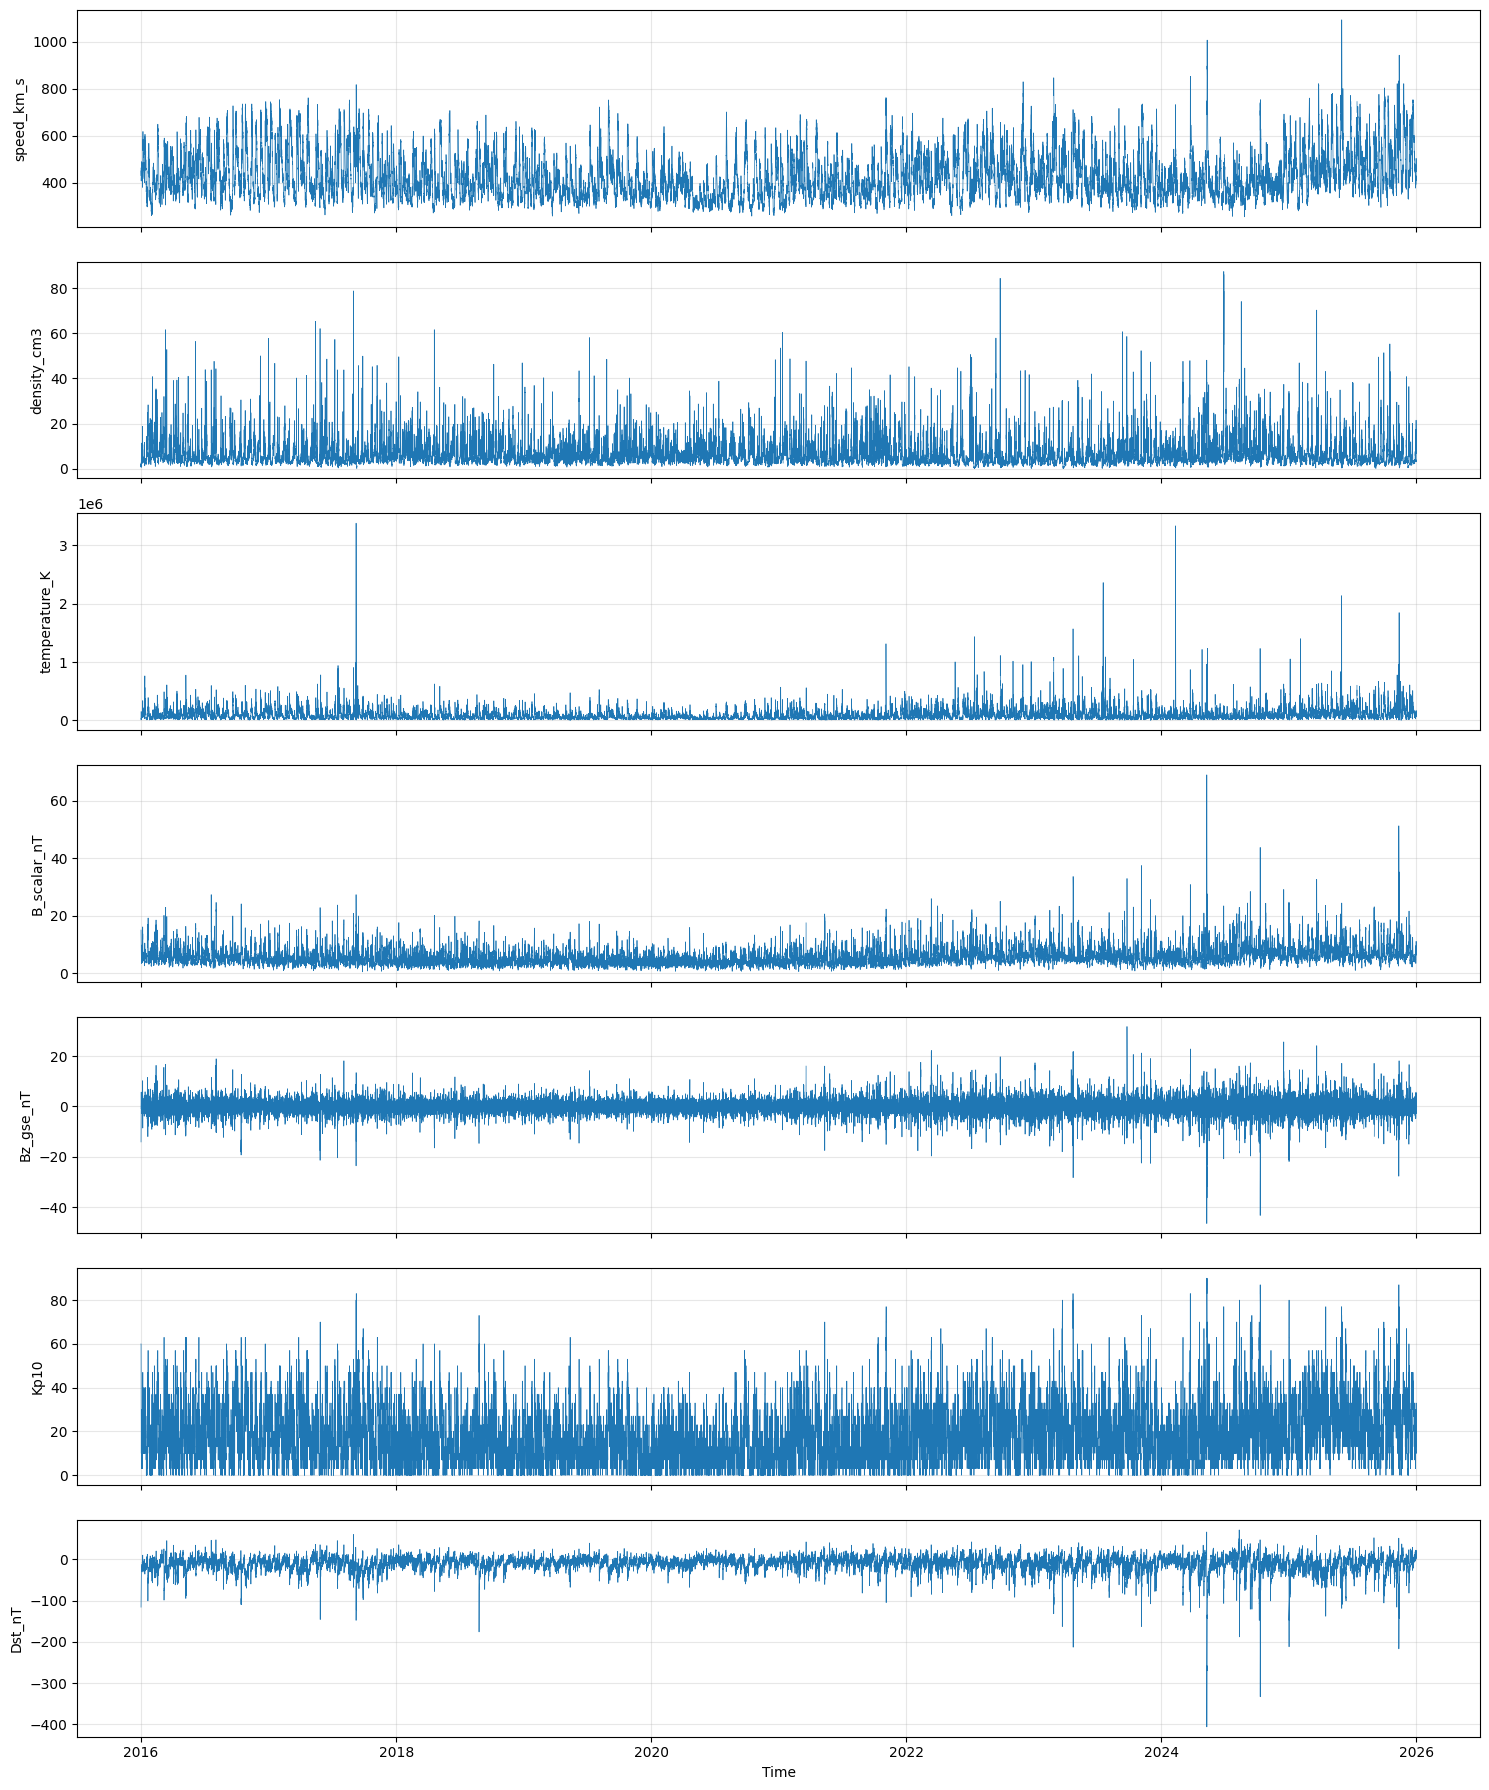

In [12]:
variables = [
    "speed_km_s",
    "density_cm3",
    "temperature_K",
    "B_scalar_nT",
    "Bz_gse_nT",
    "Kp10",
    "Dst_nT",
]

fig, axes = plt.subplots(
    len(variables), 1,
    figsize=(15, 18),
    sharex=True
)

for ax, col in zip(axes, variables):
    ax.plot(df["datetime"], df[col], linewidth=0.5)
    ax.set_ylabel(col)
    ax.grid(alpha=0.3)

axes[-1].set_xlabel("Time")

plt.tight_layout()
plt.show()

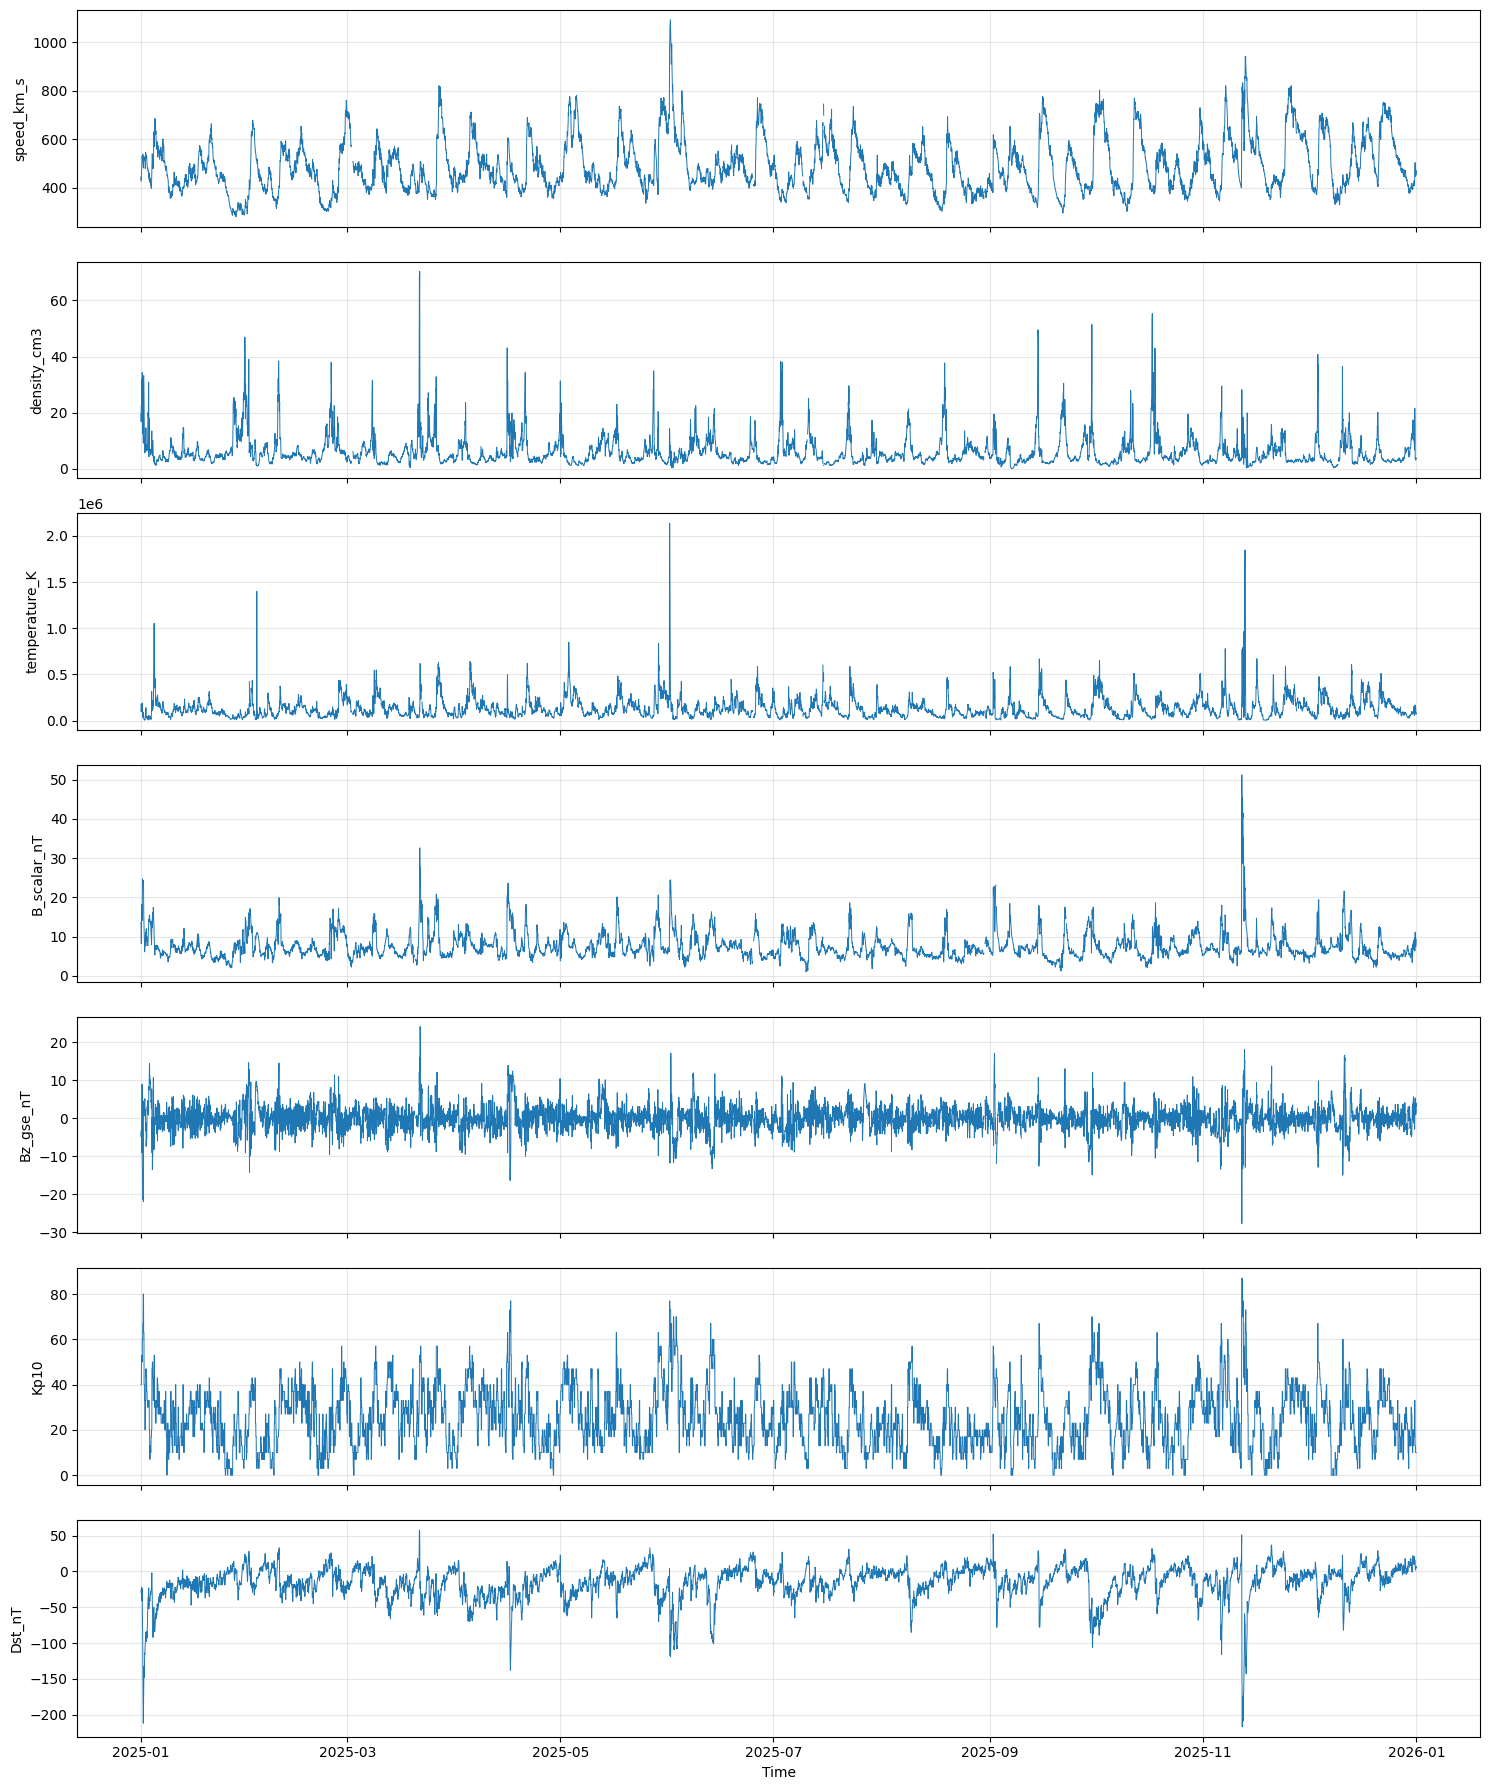

In [13]:
df_2025 = df[
    (df["datetime"] >= "2025-01-01") &
    (df["datetime"] < "2026-01-01")
]

fig, axes = plt.subplots(
    len(variables), 1,
    figsize=(15, 18),
    sharex=True
)

for ax, col in zip(axes, variables):
    ax.plot(df_2025["datetime"], df_2025[col], linewidth=0.7)
    ax.set_ylabel(col)
    ax.grid(alpha=0.3)

axes[-1].set_xlabel("Time")

plt.tight_layout()
plt.show()

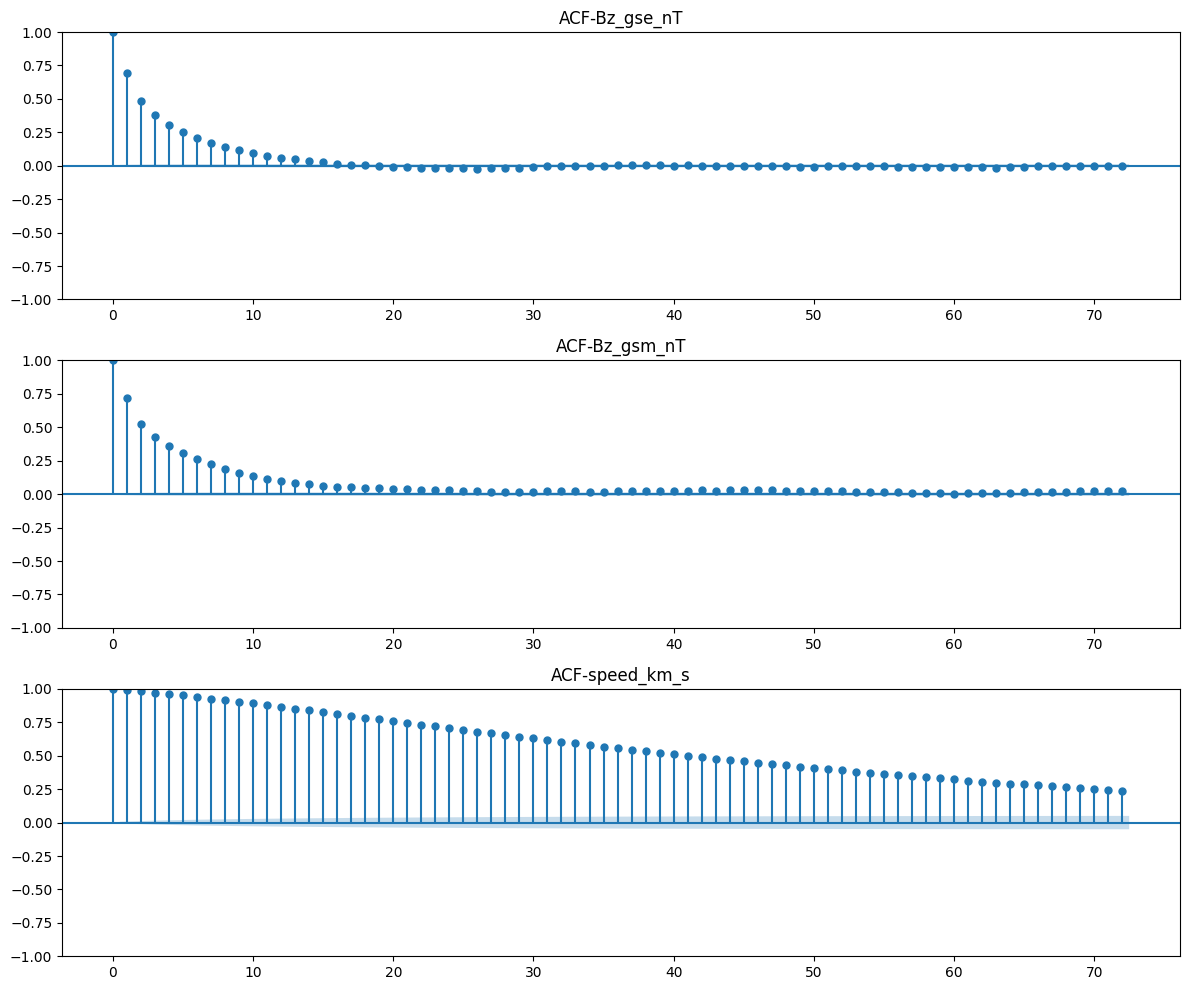

In [14]:
from statsmodels.graphics.tsaplots import plot_acf

fig,axes = plt.subplots(3,1,figsize=(12,10))
for ax,col in zip(
    axes,
    ["Bz_gse_nT","Bz_gsm_nT", "speed_km_s", "Dst_nT"]
):
    plot_acf(
        df[col].dropna(),
        lags=72,
        ax=ax,
        title=f"ACF-{col}"
    )


plt.tight_layout()
plt.show()

In [15]:
corr_cols = [
    "speed_km_s",
    "density_cm3",
    "temperature_K",
    "B_scalar_nT",
    "Bx_nT",
    "By_gse_nT",
    "Bz_gse_nT",
    "By_gsm_nT",
    "Bz_gsm_nT",
    "flow_pressure_nPa",
    "electric_field_mV_m",
    "plasma_beta",
    "alfven_mach",
    "Kp10",
    "Dst_nT",
    "AE_nT"
]

corr = df[corr_cols].corr()

corr.round(2)

,speed_km_s,density_cm3,temperature_K,B_scalar_nT,Bx_nT,By_gse_nT,Bz_gse_nT,By_gsm_nT,Bz_gsm_nT,flow_pressure_nPa,electric_field_mV_m,plasma_beta,alfven_mach,Kp10,Dst_nT,AE_nT
speed_km_s,1.00,-0.38,0.66,0.18,-0.02,0.02,0.00,0.02,-0.02,0.19,0.04,-0.22,-0.14,0.57,-0.47,0.42
density_cm3,-0.38,1.00,-0.18,0.28,-0.01,-0.03,-0.01,-0.03,0.01,0.72,-0.00,0.27,0.27,0.12,0.23,0.05
temperature_K,0.66,-0.18,1.00,0.31,-0.01,-0.00,0.01,-0.00,-0.01,0.26,0.03,-0.17,-0.21,0.50,-0.32,0.36
B_scalar_nT,0.18,0.28,0.31,1.00,-0.03,-0.02,0.00,-0.02,-0.00,0.52,0.02,-0.34,-0.57,0.54,-0.34,0.41
Bx_nT,-0.02,-0.01,-0.01,-0.03,1.00,-0.44,-0.01,-0.44,-0.00,-0.04,-0.00,-0.00,-0.00,-0.03,0.04,-0.02
By_gse_nT,0.02,-0.03,-0.00,-0.02,-0.44,1.00,-0.01,0.97,-0.02,-0.02,0.01,0.00,0.00,0.02,-0.02,0.02
Bz_gse_nT,0.00,-0.01,0.01,0.00,-0.01,-0.01,1.00,-0.01,0.91,-0.03,-0.88,-0.01,-0.02,-0.27,0.23,-0.43
By_gsm_nT,0.02,-0.03,-0.00,-0.02,-0.44,0.97,-0.01,1.00,-0.01,-0.02,0.01,0.00,0.00,0.02,-0.01,0.02
Bz_gsm_nT,-0.02,0.01,-0.01,-0.00,-0.00,-0.02,0.91,-0.01,1.00,-0.03,-0.97,-0.00,-0.01,-0.34,0.32,-0.51
flow_pressure_nPa,0.19,0.72,0.26,0.52,-0.04,-0.02,-0.03,-0.02,-0.03,1.00,0.05,0.07,0.11,0.50,-0.13,0.35


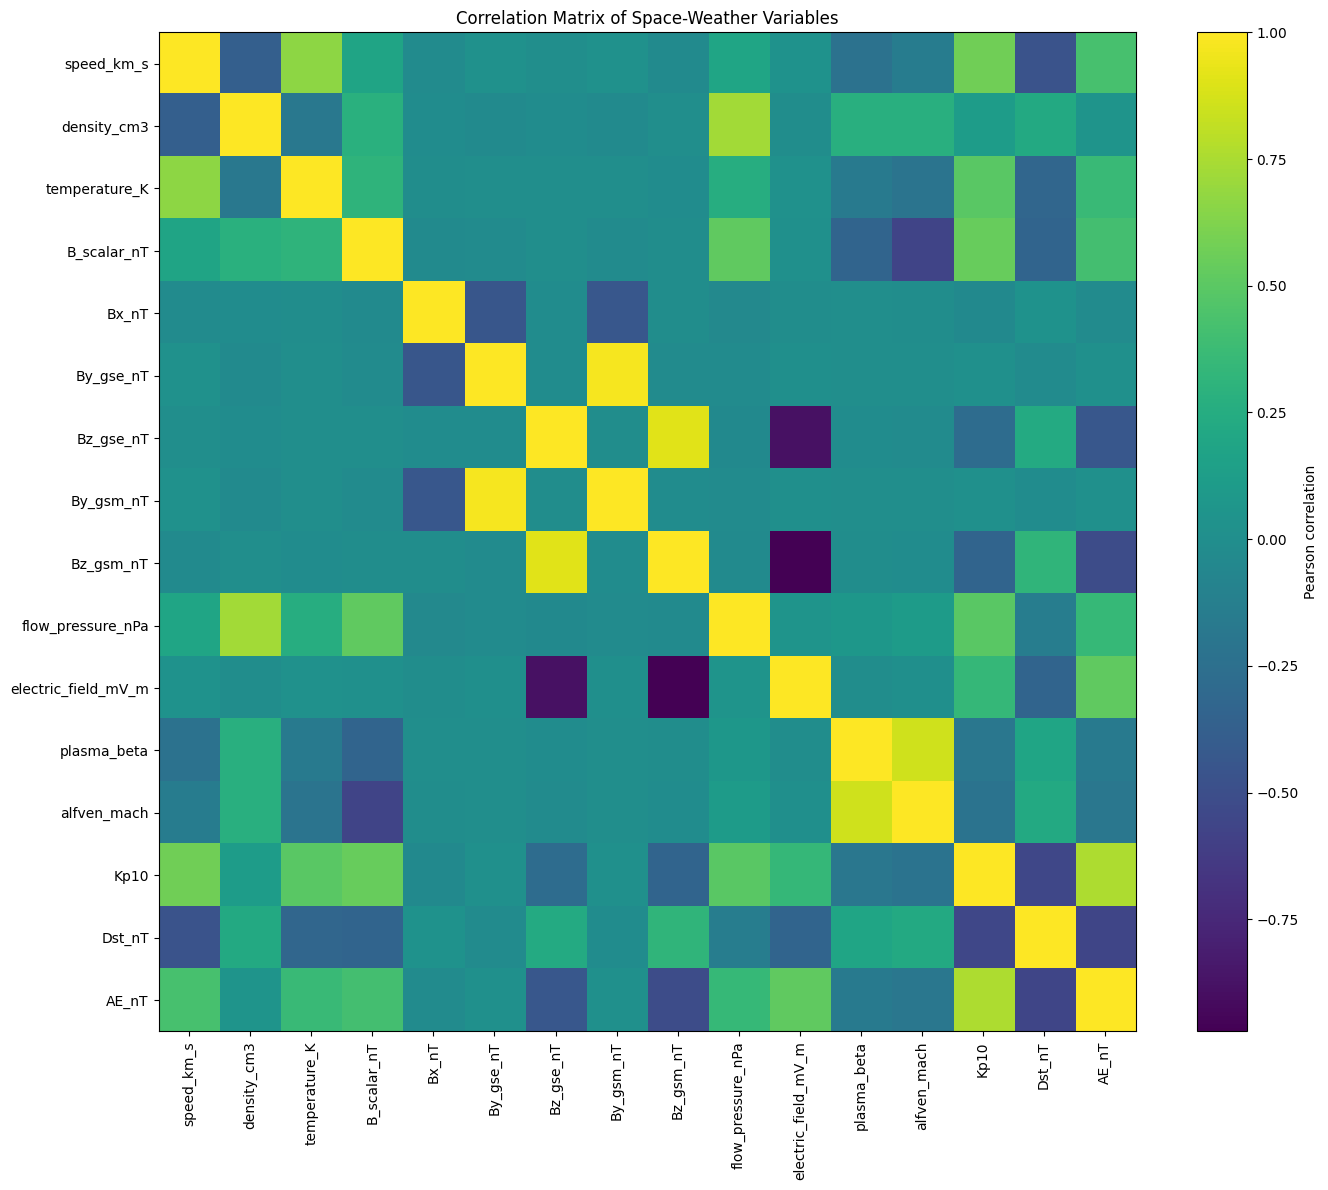

In [16]:
fig, ax = plt.subplots(figsize=(14, 12))

im = ax.imshow(
    corr,
    aspect="auto",
    interpolation="nearest"
)

ax.set_xticks(range(len(corr_cols)))
ax.set_yticks(range(len(corr_cols)))

ax.set_xticklabels(corr_cols, rotation=90)
ax.set_yticklabels(corr_cols)

fig.colorbar(im, ax=ax, label="Pearson correlation")

ax.set_title("Correlation Matrix of Space-Weather Variables")

plt.tight_layout()
plt.show()

In [17]:
dst_corr = (
    df[corr_cols]
    .corr()["Dst_nT"]
    .sort_values(ascending=False)
)

dst_corr

Dst_nT                 1.000000
Bz_gsm_nT              0.315279
Bz_gse_nT              0.230715
alfven_mach            0.228626
density_cm3            0.228160
plasma_beta            0.188848
Bx_nT                  0.036556
By_gsm_nT             -0.013600
By_gse_nT             -0.022008
flow_pressure_nPa     -0.133147
temperature_K         -0.324181
electric_field_mV_m   -0.332278
B_scalar_nT           -0.336557
speed_km_s            -0.467941
Kp10                  -0.554803
AE_nT                 -0.557677
Name: Dst_nT, dtype: float64

In [18]:
kp_corr = (
    df[corr_cols]
    .corr()["Kp10"]
    .sort_values(ascending=False)
)

kp_corr

Kp10                   1.000000
AE_nT                  0.757918
speed_km_s             0.569790
B_scalar_nT            0.544751
temperature_K          0.497935
flow_pressure_nPa      0.495451
electric_field_mV_m    0.341470
density_cm3            0.118275
By_gse_nT              0.019924
By_gsm_nT              0.019480
Bx_nT                 -0.032828
plasma_beta           -0.186963
alfven_mach           -0.219271
Bz_gse_nT             -0.272621
Bz_gsm_nT             -0.339007
Dst_nT                -0.554803
Name: Kp10, dtype: float64

In [19]:
ae_corr = (
    df[corr_cols]
    .corr()["AE_nT"]
    .sort_values(ascending=False)
)

ae_corr

AE_nT                  1.000000
Kp10                   0.757918
electric_field_mV_m    0.518737
speed_km_s             0.424705
B_scalar_nT            0.414136
temperature_K          0.364673
flow_pressure_nPa      0.348672
density_cm3            0.052603
By_gse_nT              0.020695
By_gsm_nT              0.015024
Bx_nT                 -0.022739
plasma_beta           -0.156022
alfven_mach           -0.191396
Bz_gse_nT             -0.434099
Bz_gsm_nT             -0.511511
Dst_nT                -0.557677
Name: AE_nT, dtype: float64

In [20]:
def lagged_correlation(df, predictor, target, max_lag=24):
    results = []

    for lag in range(1, max_lag + 1):
        x = df[predictor]
        y = df[target].shift(-lag)

        valid = x.notna() & y.notna()

        corr = x[valid].corr(y[valid])

        results.append({
            "lag_hours": lag,
            "correlation": corr
        })

    return pd.DataFrame(results)

In [21]:
bz_dst = lagged_correlation(
    df,
    "Bz_gsm_nT",
    "Dst_nT",
    max_lag=24
)

speed_dst = lagged_correlation(
    df,
    "speed_km_s",
    "Dst_nT",
    max_lag=24
)

density_dst = lagged_correlation(
    df,
    "density_cm3",
    "Dst_nT",
    max_lag=24
)

print("Bz → Dst")
display(bz_dst)

print("Speed → Dst")
display(speed_dst)

print("Density → Dst")
display(density_dst)

Bz → Dst


,lag_hours,correlation
0,1,0.394035
1,2,0.408878
2,3,0.391982
3,4,0.374109
4,5,0.360164
5,6,0.346973
6,7,0.330221
7,8,0.309130
8,9,0.288554
9,10,0.270869


Speed → Dst


,lag_hours,correlation
0,1,-0.472024
1,2,-0.472654
2,3,-0.470395
3,4,-0.466473
4,5,-0.461386
5,6,-0.455123
6,7,-0.447770
7,8,-0.439418
8,9,-0.430239
9,10,-0.420588


Density → Dst


,lag_hours,correlation
0,1,0.193832
1,2,0.156603
2,3,0.123786
3,4,0.095568
4,5,0.070949
5,6,0.049868
6,7,0.031652
7,8,0.015745
8,9,0.002446
9,10,-0.008610


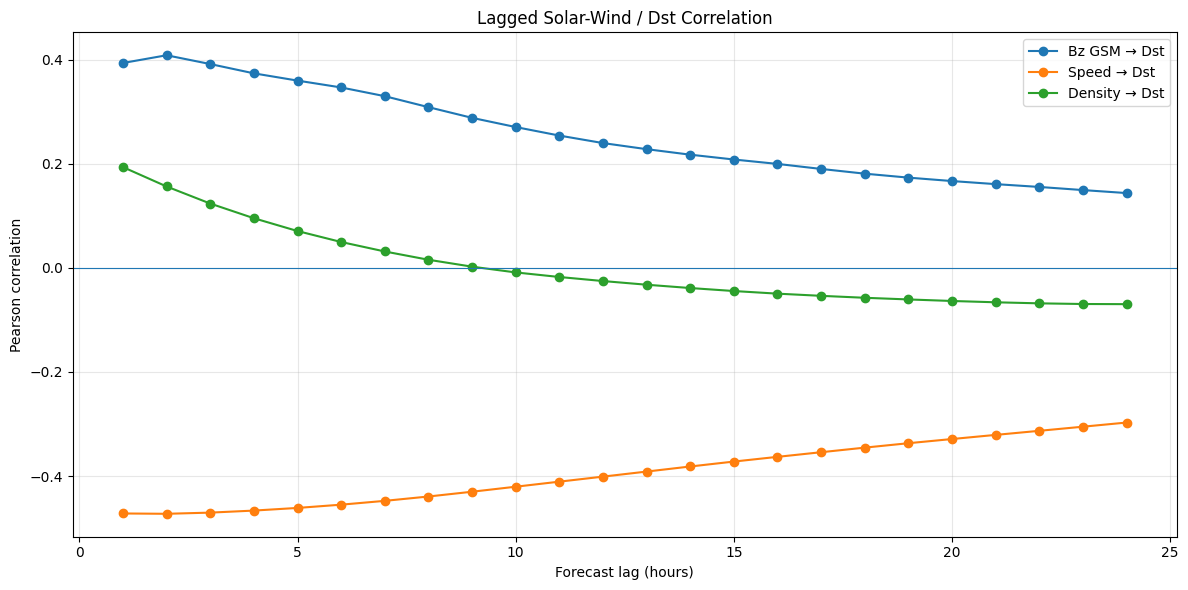

In [22]:
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(
    bz_dst["lag_hours"],
    bz_dst["correlation"],
    marker="o",
    label="Bz GSM → Dst"
)

ax.plot(
    speed_dst["lag_hours"],
    speed_dst["correlation"],
    marker="o",
    label="Speed → Dst"
)

ax.plot(
    density_dst["lag_hours"],
    density_dst["correlation"],
    marker="o",
    label="Density → Dst"
)

ax.axhline(0, linewidth=0.8)

ax.set_xlabel("Forecast lag (hours)")
ax.set_ylabel("Pearson correlation")
ax.set_title("Lagged Solar-Wind / Dst Correlation")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()